<a href="https://colab.research.google.com/github/Abdullahghazanfar/Brain-Tumor-MRI-Classifier-Using-CNN-Project/blob/main/Brain%20Tumor%20MRI%20using%20CNN%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:

\\!pip install pandas


In [ ]:
!pip install numpy

In [ ]:
!pip install matplotlib

In [ ]:
mkdir -p ~/.kaggle && echo KGAT_0dcbde55e0789f0c15a4d431ae0eaa53 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (1).json


In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 238MB/s]



In [ ]:
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [ ]:
!ls

 brain-tumor-mri-dataset.zip   kaggle.json   Testing
'kaggle (1).json'	       sample_data   Training


In [ ]:
# data catagories of images
import os

train_dir = './Training'
test_dir = './Testing'

# List the folders inside the Training directory
classes = os.listdir(train_dir)
print(f"Found {len(classes)} tumor categories:")
for category in classes:
    # Count how many images are in each category folder
    num_images = len(os.listdir(os.path.join(train_dir, category)))
    print(f"- {category}: {num_images} images")

Found 4 tumor categories:
- pituitary: 1400 images
- notumor: 1400 images
- glioma: 1400 images
- meningioma: 1400 images


In [ ]:
import tensorflow as tf

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    './Training',
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print("\nLoading Testing Data:")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    './Testing',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Optimize for Colab's memory
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("\nDatasets successfully optimized and ready for training!")

Loading Training Data:
Found 5600 files belonging to 4 classes.

Loading Testing Data:
Found 1600 files belonging to 4 classes.

Datasets successfully optimized and ready for training!


In [ ]:
from tensorflow.keras import layers, models

# 1. Define Model Architecture
model = models.Sequential([
    # Rescale pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Conv Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(4, activation='softmax') # 4 classes
])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 1. Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled! Starting training...")

# 2. Train the Model (This will take a few minutes)
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

Model compiled! Starting training...
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 31s 122ms/step - accuracy: 0.7107 - loss: 0.7098 - val_accuracy: 0.7350 - val_loss: 0.8640
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.8509 - loss: 0.3944 - val_accuracy: 0.7812 - val_loss: 0.9255
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.8991 - loss: 0.2723 - val_accuracy: 0.8125 - val_loss: 0.8836
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9334 - loss: 0.1808 - val_accuracy: 0.8238 - val_loss: 1.0680
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9484 - loss: 0.1421 - val_accuracy: 0.8331 - val_loss: 0.8866
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9582 - loss: 0.1076 - val_accuracy: 0.8700 - val_loss: 0.9322
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9711 - loss: 0.0821 - val_accuracy: 0.8763 - val_loss: 1.0111
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - ac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


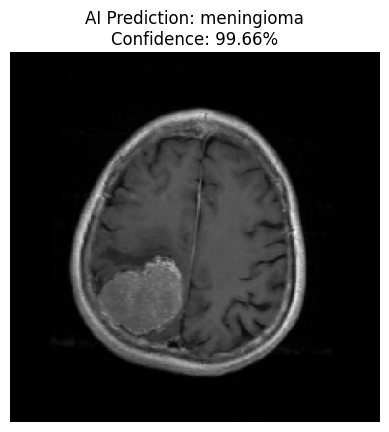

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Grab a path to a single MRI image
# (Open your Colab file explorer, go to Testing -> glioma, right-click an image and "Copy path")
image_path = '/content/Testing/meningioma/Te-aug-me_36.jpg' # Replace this with your copied path!

# 2. Load the image and resize it to match the model's expected input (224x224)
img = tf.keras.utils.load_img(image_path, target_size=(224, 224))

# 3. Convert the image into a numpy array
img_array = tf.keras.utils.img_to_array(img)

# 4. Add the batch dimension! (Changes shape from 224,224,3 to 1,224,224,3)
img_array = tf.expand_dims(img_array, 0)

# 5. Make the prediction
predictions = model.predict(img_array)

# 6. Extract the class names from your original dataset
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# 7. Find the highest probability prediction
predicted_class = class_names[np.argmax(predictions[0])]
confidence = np.max(predictions[0]) * 100

# 8. Display the image with the prediction!
plt.imshow(img)
plt.title(f"AI Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.axis("off")
plt.show()

1. Extracting actual labels from the testing dataset...
2. Generating AI predictions for all test images...
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
3. Building the Confusion Matrix...


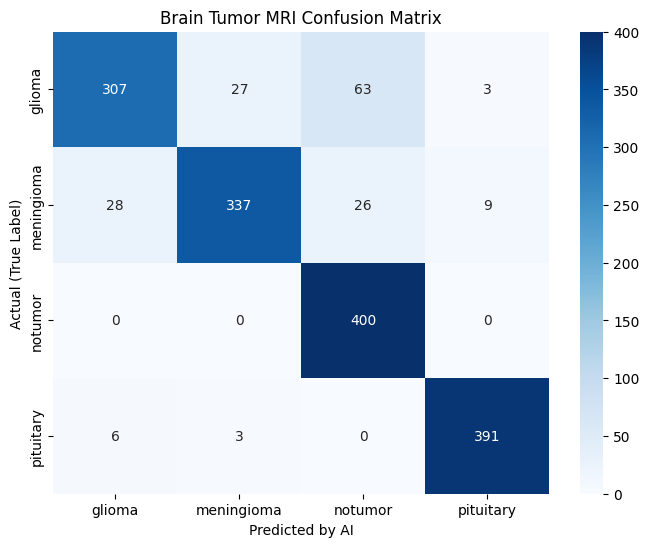


Classification Report:

              precision    recall  f1-score   support

      glioma       0.90      0.77      0.83       400
  meningioma       0.92      0.84      0.88       400
     notumor       0.82      1.00      0.90       400
   pituitary       0.97      0.98      0.97       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("1. Extracting actual labels from the testing dataset...")
# We can do this safely because we set shuffle=False when loading the testing data
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

print("2. Generating AI predictions for all test images...")
predictions = model.predict(test_dataset)
# Convert percentage confidence into the final predicted class number (0, 1, 2, or 3)
y_pred = np.argmax(predictions, axis=1)

print("3. Building the Confusion Matrix...")
# The classes we defined earlier
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Generate the math matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plot it visually!
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted by AI')
plt.ylabel('Actual (True Label)')
plt.title('Brain Tumor MRI Confusion Matrix')
plt.show()

# 5. Print a detailed text report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
!pip install -q -U google-genai